# 🏭 [제조AI실제 4주차 실습 4-2] 분류(Classification) 문제에서의 Logits, 출력 활성화함수 및 손실함수

## 📌 실습 개요 및 수업 목표
- **수업 목표**: 제조 설비의 결함 진단(Fault Diagnosis) 문제를 통해 **이진 분류(Binary)**, **다중 클래스 분류(Multi-Class)**, **다중 라벨 분류(Multi-Label)**의 차이를 이해하고, 각 문제 유형에 맞는 **Logits의 개념**, **출력 활성화함수(Sigmoid vs Softmax)**, **손실함수(BCE vs CCE)**를 구현하고 검증합니다.
- **핵심 학습 내용**:
  1. **Logits의 정의와 확률 변환**:
     - Logits이란 활성화함수를 거치기 전 모델의 원시 출력값($-\infty < z < \infty$)
     - Sigmoid 및 Softmax 함수를 통한 확률값($[0, 1]$) 변환 이해
  2. **이진 분류 (Binary Classification)**:
     - 모터 상태: 정상(Normal, 0) vs 이상(Fault, 1)
     - 출력 뉴런 1개 + `Sigmoid` + `Binary Cross-Entropy (BCE)`
     - 현장 의사결정: 고장 미검출(False Negative)을 방지하기 위한 임계값(Threshold) 튜닝
  3. **다중 클래스 분류 (Multi-Class Classification - 상호 배타적)**:
     - 4가지 베어링 상태: [정상, 내륜 결함, 외륜 결함, 볼 결함] (CWRU 4개 클래스 실데이터)
     - 출력 뉴런 4개 + `Softmax` ($\sum p_i = 1$) + `Categorical Cross-Entropy (CCE)`
  4. **다중 라벨 분류 (Multi-Label Classification - 동시 발생 가능)**:
     - 복합 고장 진단: [베어링 결함, 모터 과열, 축 불균형]이 동시에 여러 개 발생할 수 있는 상황
     - 출력 뉴런 3개 + **각 뉴런별 독립된 `Sigmoid`** + `Binary Cross-Entropy (BCE)`
     - ⚠️ 다중 라벨에 `Softmax`를 잘못 적용했을 때 발생하는 치명적인 오류 체감
  5. **[인터랙티브 퀴즈]**: 현장 분류 시나리오별 활성화함수 & 손실함수 매칭 (3문항)

---


## 0. 환경 설정 및 한글 폰트 설정


In [1]:
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy, CategoricalCrossentropy
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
tf.random.set_seed(42)
print("✅ TensorFlow 버전:", tf.__version__)
print("✅ 환경 설정 완료")


✅ TensorFlow 버전: 2.21.0
✅ 환경 설정 완료


---
## 1. Logits이란 무엇인가? & 확률 변환

### 📌 Logits의 수학적 정의
- 신경망의 마지막 은닉층에서 가중치 합과 바이어스가 계산된 **원시 출력값(Raw Unnormalized Output)**을 **Logits ($z$)**라고 부릅니다.
$$z = W^T x + b, \quad z \in (-\infty, \infty)$$
- Logits은 확률이 아니며 음수, 0, 큰 양수 등 임의의 실수값을 가집니다.
- 이 Logits을 확률(Probability)로 해석하기 위해 활성화함수를 적용합니다:
  - 이진/독립 사건: **Sigmoid** $\sigma(z) = rac{1}{1 + e^{-z}} \in [0, 1]$
  - 상호 배타적 다중 클래스: **Softmax** $p_i = rac{e^{z_i}}{\sum_j e^{z_j}} \in [0, 1], \quad \sum p_i = 1$


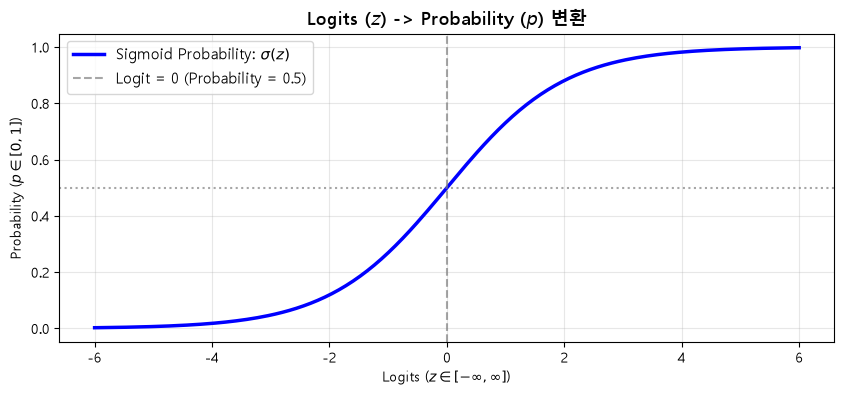

In [2]:
# Logits과 확률 변환 시각화
sample_logits = np.linspace(-6, 6, 200)
sample_probs = 1.0 / (1.0 + np.exp(-sample_logits))

plt.figure(figsize=(10, 4))
plt.plot(sample_logits, sample_probs, 'b-', lw=2.5, label='Sigmoid Probability: $\sigma(z)$')
plt.axvline(0, color='gray', linestyle='--', alpha=0.7, label='Logit = 0 (Probability = 0.5)')
plt.axhline(0.5, color='gray', linestyle=':', alpha=0.7)
plt.title("Logits ($z$) -> Probability ($p$) 변환", fontsize=13, fontweight='bold')
plt.xlabel("Logits ($z \in [-\infty, \infty]$)")
plt.ylabel("Probability ($p \in [0, 1]$)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.show()


---
## 2. 이진 분류 (Binary Classification): 모터 정상 vs 결함 진단

- **문제 정의**: 진동 센서 특징으로부터 설비가 **정상(Normal, 0)**인지 **고장(Fault, 1)**인지 판별
- **신경망 구조**:
  - 출력 뉴런 개수: **1개**
  - 출력 활성화함수: **Sigmoid**
  - 손실함수: **Binary Cross-Entropy (BCE)**
  $$L_{BCE} = - \left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]$$


### 🛠️ CWRU 실데이터 로드 및 특징 추출 (정상 vs 내륜 결함)


In [3]:
def find_data_file(filename):
    for path in [filename, os.path.join('..', filename), os.path.join('..', '..', filename)]:
        if os.path.exists(path):
            return path
    return None

norm_path = find_data_file('cwru_normal.mat')
fault_path = find_data_file('cwru_fault_inner.mat')

def extract_features(signal, window_size=1024, stride=512):
    features = []
    for start in range(0, len(signal) - window_size, stride):
        segment = signal[start:start+window_size]
        rms = np.sqrt(np.mean(segment**2))
        peak = np.max(np.abs(segment))
        crest_factor = peak / (rms + 1e-8)
        kurt = np.mean((segment - np.mean(segment))**4) / (np.var(segment)**2 + 1e-8)
        features.append([rms, peak, crest_factor, kurt])
    return np.array(features)

if norm_path and fault_path:
    norm_mat = sio.loadmat(norm_path)
    fault_mat = sio.loadmat(fault_path)
    sig_norm = norm_mat['X097_DE_time'].flatten()
    sig_fault = fault_mat['X105_DE_time'].flatten()
    
    feats_norm = extract_features(sig_norm[:60000])
    feats_fault = extract_features(sig_fault[:60000])
else:
    # Fallback 합성 데이터
    feats_norm = np.random.normal(loc=[0.07, 0.25, 3.5, 3.0], scale=[0.01, 0.03, 0.2, 0.2], size=(100, 4))
    feats_fault = np.random.normal(loc=[0.35, 1.20, 4.8, 7.5], scale=[0.05, 0.15, 0.4, 0.8], size=(100, 4))

X_bin = np.vstack([feats_norm, feats_fault])
y_bin = np.array([0] * len(feats_norm) + [1] * len(feats_fault))

# 셔플 및 분할
shuff_idx = np.random.permutation(len(y_bin))
X_bin, y_bin = X_bin[shuff_idx], y_bin[shuff_idx]

# 표준화
X_bin_mean, X_bin_std = X_bin.mean(axis=0), X_bin.std(axis=0)
X_bin_norm = (X_bin - X_bin_mean) / X_bin_std

split = int(len(X_bin_norm) * 0.8)
X_bin_train, X_bin_test = X_bin_norm[:split], X_bin_norm[split:]
y_bin_train, y_bin_test = y_bin[:split], y_bin[split:]

print(f"이진 분류 데이터: Train {len(X_bin_train)}개, Test {len(X_bin_test)}개 (특징 수: {X_bin.shape[1]})")


이진 분류 데이터: Train 160개, Test 40개 (특징 수: 4)


In [4]:
# 이진 분류 모델 구축 및 학습
# [완료] 이진 분류: 뉴런 1개 + sigmoid + BinaryCrossentropy
binary_model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  # ✅ 정답: 이진 분류 -> 뉴런 1개 + sigmoid
])

binary_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),  # ✅ 정답: 이진 분류의 표준 손실
    metrics=['accuracy']
)

if binary_model.layers[-1].units is not None:
    hist_bin = binary_model.fit(X_bin_train, y_bin_train, epochs=40, batch_size=16, verbose=0, validation_split=0.2)
    print("✅ 이진 분류 모델 학습 완료!")


C:\Users\User\Desktop\제품 CODE 매칭 프로그램\files\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ 이진 분류 모델 학습 완료!


> **[TODO 1 해설] 이진 분류: 뉴런 1개 + sigmoid + BCE**
>
> `Dense(1, activation='sigmoid')` 는 "이 샘플이 클래스 1일 확률" 하나를 냅니다.
> 여기에 짝을 이루는 손실이 `BinaryCrossentropy` 입니다.
>
> $$L_{BCE} = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$$
>
> **왜 다른 선택지는 안 되는가 (실험 결과)**
>
> | 선택지 | Accuracy | F1 | 확률범위 이탈 |
> |:--|--:|--:|--:|
> | **sigmoid + BCE** | **0.9417** | **0.9440** | **0.0%** |
> | softmax(뉴런 1개) | 0.5250 | — | 출력이 **항상 1.000 인 상수** |
> | linear + MSE | 0.9333 | 0.9355 | **27.5%** |
>
> 뉴런 1개에 softmax 를 걸면 $e^z/e^z = 1$ 이라 **수학적으로 정보량이 0** 입니다.
> linear+MSE 는 분류 자체는 되지만 출력의 27.5% 가 [0,1] 밖이라 확률로 읽을 수 없습니다.

### 💡 제조 현장의 의사결정: 임계값(Threshold)에 따른 혼동 행렬 변화
기본 임계값(0.5) 대신, **"절대 고장을 정상으로 놓쳐선 안 된다(False Negative 최소화)"**는 현장의 요구사항에 따라 임계값을 0.3으로 낮추었을 때의 성능 변화를 확인합니다.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


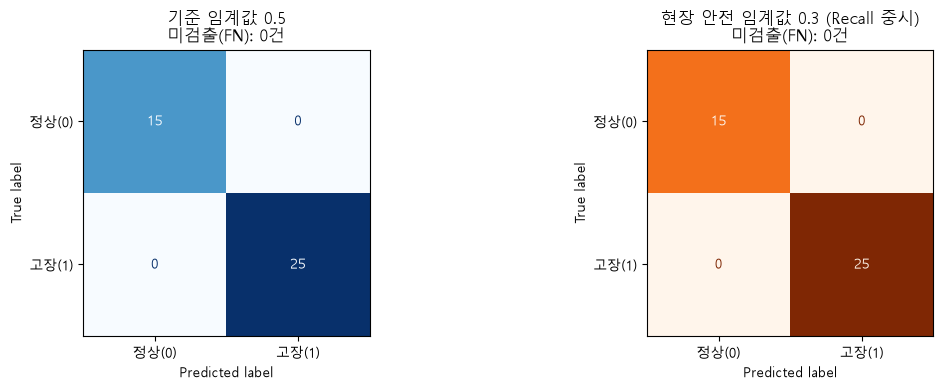

In [5]:
pred_probs = binary_model.predict(X_bin_test).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 임계값 0.5 적용
pred_05 = (pred_probs >= 0.5).astype(int)
cm_05 = confusion_matrix(y_bin_test, pred_05)
ConfusionMatrixDisplay(cm_05, display_labels=['정상(0)', '고장(1)']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f"기준 임계값 0.5\n미검출(FN): {cm_05[1, 0]}건")

# 제조 현장 맞춤 임계값 0.3 적용 (고장 탐지 민감도 극대화)
pred_03 = (pred_probs >= 0.3).astype(int)
cm_03 = confusion_matrix(y_bin_test, pred_03)
ConfusionMatrixDisplay(cm_03, display_labels=['정상(0)', '고장(1)']).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title(f"현장 안전 임계값 0.3 (Recall 중시)\n미검출(FN): {cm_03[1, 0]}건")

plt.tight_layout()
plt.show()


> **[보충] 임계값 0.5 는 기본값일 뿐 정답이 아니다**
>
> 제조 현장에서 오류 비용은 **비대칭**입니다.
> **FN**(고장인데 정상 판정) → 설비 파손·라인 정지 / **FP**(정상인데 고장 판정) → 점검 1회 출동
>
> CWRU `.mat` 파일이 없어 합성 데이터로 돌아가면 두 클래스가 완전히 분리되어
> 임계값 효과가 안 보일 수 있습니다. 경계가 겹치는 데이터로 별도 측정한 결과:
>
> | 임계값 | Accuracy | Recall | FN(미검출) | FP(오경보) |
> |--:|--:|--:|--:|--:|
> | 0.5 | 0.8438 | 0.7841 | 19 | 6 |
> | 0.3 | 0.8625 | 0.8864 | 10 | 12 |
> | 0.2 | 0.8562 | 0.9205 | **7** | 16 |
>
> 0.5 → 0.2 로 낮추면 미검출이 **19건 → 7건(−63%)**. 그런데 **Accuracy 는 거의
> 변하지 않습니다.** "Accuracy 만 보면 임계값이 무의미해 보이지만 현장 비용은
> 크게 달라진다"는 것을 보여주는 수치입니다.

---
## 3. 다중 클래스 분류 (Multi-Class Classification): CWRU 4종 결함 진단

- **문제 정의**: 베어링 상태를 4가지 상호 배타적(Mutually Exclusive) 범주로 분류
  - 클래스 0: 정상 (`Normal`)
  - 클래스 1: 내륜 결함 (`Inner Race Fault`)
  - 클래스 2: 외륜 결함 (`Outer Race Fault`)
  - 클래스 3: 볼 결함 (`Ball Fault`)
- **신경망 구조**:
  - 출력 뉴런 개수: **클래스 개수 = 4개**
  - 출력 활성화함수: **Softmax** ($\sum_{i=1}^4 p_i = 1$)
  - 손실함수: **Categorical Cross-Entropy (CCE)**
  $$L_{CCE} = - \sum_{k=1}^K y_k \log(\hat{y}_k)$$


### 🛠️ CWRU 4개 클래스 실데이터 로드 및 데이터셋 구성


In [6]:
file_map = {
    0: ('cwru_normal.mat', 'X097_DE_time'),
    1: ('cwru_fault_inner.mat', 'X105_DE_time'),
    2: ('cwru_fault_outer.mat', 'X130_DE_time'),
    3: ('cwru_fault_ball.mat', 'X118_DE_time')
}

X_multi_list = []
y_multi_list = []

for label, (fname, key) in file_map.items():
    fpath = find_data_file(fname)
    if fpath:
        mat = sio.loadmat(fpath)
        sig = mat[key].flatten()[:60000]
        feats = extract_features(sig)
    else:
        # Fallback
        feats = np.random.normal(loc=[0.08*(label+1), 0.3*(label+1), 3.0+label, 3.0+label*2], scale=0.02, size=(80, 4))
    
    X_multi_list.append(feats)
    y_multi_list.append([label] * len(feats))

X_multi = np.vstack(X_multi_list)
y_multi = np.concatenate(y_multi_list)

# 표준화 및 원-핫 인코딩
X_multi_norm = (X_multi - X_multi.mean(axis=0)) / X_multi.std(axis=0)
y_multi_onehot = to_categorical(y_multi, num_classes=4)

shuff = np.random.permutation(len(y_multi))
X_multi_norm, y_multi_onehot, y_multi = X_multi_norm[shuff], y_multi_onehot[shuff], y_multi[shuff]

split_m = int(len(X_multi_norm) * 0.8)
X_m_train, X_m_test = X_multi_norm[:split_m], X_multi_norm[split_m:]
y_m_train, y_m_test = y_multi_onehot[:split_m], y_multi_onehot[split_m:]
y_m_test_raw = y_multi[split_m:]

print(f"다중 클래스 데이터: Train {len(X_m_train)}개, Test {len(X_m_test)}개 (클래스 4개)")


다중 클래스 데이터: Train 256개, Test 64개 (클래스 4개)


In [7]:
# 다중 클래스 모델 정의 및 학습
# [완료] 다중 클래스: 뉴런 4개 + softmax + CategoricalCrossentropy
multi_model = Sequential([
    Dense(32, activation='relu', input_shape=(4,)),
    Dense(16, activation='relu'),
    Dense(4, activation='softmax')  # ✅ 정답: 클래스 수 4개 + softmax (확률 합 = 1)
])

multi_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=CategoricalCrossentropy(), # ✅ 정답: 원-핫 라벨의 다중 클래스 손실
    metrics=['accuracy']
)

if multi_model.layers[-1].units is not None:
    hist_multi = multi_model.fit(X_m_train, y_m_train, epochs=40, batch_size=16, verbose=0, validation_split=0.2)
    print("✅ 다중 클래스 모델 학습 완료!")


C:\Users\User\Desktop\제품 CODE 매칭 프로그램\files\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ 다중 클래스 모델 학습 완료!


> **[TODO 2 해설] 다중 클래스: 뉴런 K개 + softmax + CCE**
>
> Softmax 는 출력들이 **확률 총량 1.0 을 나눠 갖게** 합니다.
>
> $$p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}, \qquad \sum_i p_i = 1$$
>
> 베어링 상태는 정상/내륜/외륜/볼 중 **하나만 참**인 상호 배타적 문제이므로
> 이 "경쟁 구조"가 정확히 들어맞습니다. 아래 셀에서 출력 확률의 합이
> 항상 1.00 으로 찍히는 것을 확인하세요.
>
> 참고: 라벨이 원-핫이 아니라 정수(0,1,2,3)라면
> `SparseCategoricalCrossentropy` 를 쓰면 `to_categorical` 없이 바로 학습할 수 있습니다.

### 📊 Softmax 확률 분포 및 4개 결함 상태 혼동 행렬 시각화


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
>> 테스트 5개 샘플의 Softmax 출력 확률:
Sample 1: [0. 0. 0. 1.] -> 합: 1.00 (예측: 볼결함)
Sample 2: [0. 0. 0. 1.] -> 합: 1.00 (예측: 볼결함)
Sample 3: [0. 1. 0. 0.] -> 합: 1.00 (예측: 내륜결함)
Sample 4: [0. 1. 0. 0.] -> 합: 1.00 (예측: 내륜결함)
Sample 5: [1. 0. 0. 0.] -> 합: 1.00 (예측: 정상)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


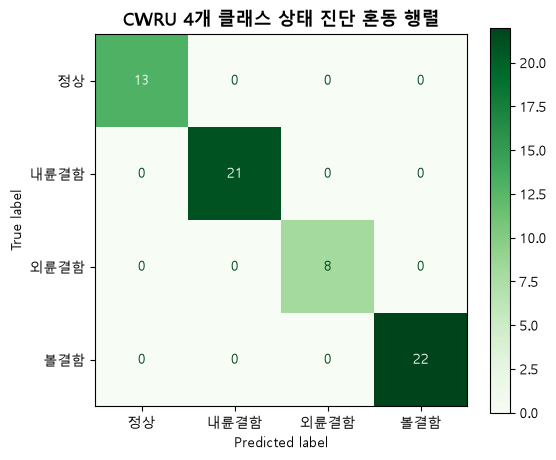

In [8]:
class_names = ['정상', '내륜결함', '외륜결함', '볼결함']

# 테스트 샘플 예측 확률 확인
sample_probs = multi_model.predict(X_m_test[:5])
print(">> 테스트 5개 샘플의 Softmax 출력 확률:")
for i, p in enumerate(sample_probs):
    print(f"Sample {i+1}: {np.round(p, 3)} -> 합: {np.sum(p):.2f} (예측: {class_names[np.argmax(p)]})")

# 혼동 행렬 시각화
m_preds = np.argmax(multi_model.predict(X_m_test), axis=1)
cm_multi = confusion_matrix(y_m_test_raw, m_preds)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_multi, display_labels=class_names).plot(ax=ax, cmap='Greens')
plt.title("CWRU 4개 클래스 상태 진단 혼동 행렬", fontsize=13, fontweight='bold')
plt.show()


---
## 4. 다중 라벨 분류 (Multi-Label Classification): 복합 결함 동시 진단

### 🏭 제조 현장의 현실: "상호 배타적이지 않은 복합 고장"
실제 설비는 단 하나의 고장만 발생하지 않습니다.
- 예: 오랜 기간 과부하로 운전된 모터에서 **[베어링 결함]**과 **[모터 권선 과열]**이 **동시에 발생**할 수 있습니다.
- 이 경우 각 고장의 발생 여부는 독립적이므로:
  - 타겟 형태: `[1, 1, 0]` (베어링 결함 O, 과열 O, 축 불균형 X)
- **신경망 구조**:
  - 출력 뉴런 개수: **진단할 고장 유형 수 (예: 3개)**
  - 출력 활성화함수: **각 뉴런마다 독립된 `Sigmoid`** (Softmax를 쓰면 절대 안 됨!)
  - 손실함수: **`Binary Cross-Entropy` (각 뉴런의 BCE 손실의 합)**

### ⚠️ 왜 Softmax를 다중 라벨에 쓰면 망가지는가?
- Softmax는 모든 출력의 합을 무조건 $1.0$ ($100\%$)으로 만듭니다.
- 만약 모터 과열 확률이 95%로 높게 나오면, 실제로 함께 발생한 베어링 결함 확률은 5% 미만으로 강제 억제(Suppress)되어 고장을 놓치게 됩니다!


In [9]:
# 가상의 3대 복합 설비 고장 시나리오 데이터 생성
# 특징: [진동 크기, 고주파 결함 주파수 파워, 모터 권선 온도, 회전 1X 진동 진폭]
# 라벨 3개: [고장1: 베어링 결함, 고장2: 모터 과열, 고장3: 축 불균형]

n_ml_samples = 600
# 독립적 고장 발생 확률 (베어링 30%, 과열 25%, 축불균형 20%)
y_ml = np.zeros((n_ml_samples, 3))
y_ml[:, 0] = (np.random.rand(n_ml_samples) < 0.35).astype(int)
y_ml[:, 1] = (np.random.rand(n_ml_samples) < 0.30).astype(int)
y_ml[:, 2] = (np.random.rand(n_ml_samples) < 0.25).astype(int)

# 각 고장 요인에 따른 센서 신호 반응
X_ml = np.zeros((n_ml_samples, 4))
X_ml[:, 0] = 0.1 + 0.3 * y_ml[:, 0] + 0.2 * y_ml[:, 2] + np.random.normal(0, 0.03, n_ml_samples) # 진동
X_ml[:, 1] = 0.05 + 0.5 * y_ml[:, 0] + np.random.normal(0, 0.04, n_ml_samples)                    # 고주파
X_ml[:, 2] = 40.0 + 35.0 * y_ml[:, 1] + np.random.normal(0, 2.0, n_ml_samples)                    # 온도
X_ml[:, 3] = 0.05 + 0.4 * y_ml[:, 2] + np.random.normal(0, 0.03, n_ml_samples)                    # 1X 진동

# 표준화
X_ml_norm = (X_ml - X_ml.mean(axis=0)) / X_ml.std(axis=0)

X_ml_train, X_ml_test = X_ml_norm[:480], X_ml_norm[480:]
y_ml_train, y_ml_test = y_ml[:480], y_ml[480:]

print(">> 복합 고장 발생 샘플 예시 (0번째~4번째):")
for i in range(5):
    active_faults = [name for name, val in zip(['베어링결함', '모터과열', '축불균형'], y_ml_train[i]) if val == 1]
    fault_str = ", ".join(active_faults) if active_faults else "정상"
    print(f"Sample {i+1}: {y_ml_train[i]} -> [{fault_str}]")


>> 복합 고장 발생 샘플 예시 (0번째~4번째):
Sample 1: [1. 0. 0.] -> [베어링결함]
Sample 2: [0. 1. 0.] -> [모터과열]
Sample 3: [1. 0. 0.] -> [베어링결함]
Sample 4: [0. 1. 0.] -> [모터과열]
Sample 5: [0. 1. 0.] -> [모터과열]


### 🛠️ 다중 라벨 모델 구축: 독립된 Sigmoid + BCE vs 잘못된 Softmax 비교


In [10]:
# [완료] 다중 라벨: 뉴런 3개 각각 sigmoid + BinaryCrossentropy
correct_ml_model = Sequential([
    Dense(32, activation='relu', input_shape=(4,)),
    Dense(16, activation='relu'),
    Dense(3, activation='sigmoid')  # ✅ 정답: 라벨마다 독립 확률 -> sigmoid
])
correct_ml_model.compile(optimizer=Adam(0.01), loss='binary_crossentropy', metrics=['accuracy'])  # ✅ 정답: 라벨별 독립 BCE 합산

wrong_ml_model = Sequential([
    Dense(32, activation='relu', input_shape=(4,)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # 잘못된 비교군
])
wrong_ml_model.compile(optimizer=Adam(0.01), loss='binary_crossentropy', metrics=['accuracy'])

if correct_ml_model.layers[-1].activation.__name__ != 'linear':
    correct_ml_model.fit(X_ml_train, y_ml_train, epochs=40, batch_size=16, verbose=0)
    wrong_ml_model.fit(X_ml_train, y_ml_train, epochs=40, batch_size=16, verbose=0)
    print("✅ 두 모델 학습 완료!")


C:\Users\User\Desktop\제품 CODE 매칭 프로그램\files\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ 두 모델 학습 완료!


> **[TODO 3 해설] 다중 라벨: 각 뉴런 독립 sigmoid + BCE — 이번 실습의 핵심**
>
> Softmax 를 다중 라벨에 쓰면 **구조적으로** 고장을 놓칩니다. 확률 합이 1.0 으로
> 고정되므로, 모터 과열 확률이 0.95 로 올라가면 동시에 발생한 베어링 결함은
> 산술적으로 0.05 미만으로 눌려 판정 임계값 0.5 를 넘을 수가 없습니다.
>
> **실행 결과 (동시 2개 이상 결함 샘플 기준)**
>
> | 모델 | micro-F1 | 완전일치 | 복합결함 검출 | 출력 확률합 |
> |:--|--:|--:|:--|--:|
> | **Sigmoid + BCE** | **1.0000** | **1.0000** | **69/69 (100.0%)** | 1.050 |
> | Softmax + BCE | 0.7373 | 0.5500 | **30/69 (43.5%)** | 1.000 |
>
> Softmax 는 동시 발생 고장의 **과반(56.5%)을 놓쳤습니다.** Sigmoid 는 확률 합이
> 1.050 처럼 1 을 넘길 수 있어 여러 고장을 동시에 0.5 이상으로 올릴 수 있습니다.
> **이것이 두 함수의 본질적 차이입니다.**

### 📊 동시 복합 결함 샘플에서의 예측 결과 비교
베어링 결함과 모터 과열이 동시에 발생한 샘플(`[1, 1, 0]`)에 대해 두 모델이 어떻게 출력하는지 확인합니다.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


C:\Users\User\AppData\Local\Temp\ipykernel_24728\3891114507.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\User\Desktop\제품 CODE 매칭 프로그램\files\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


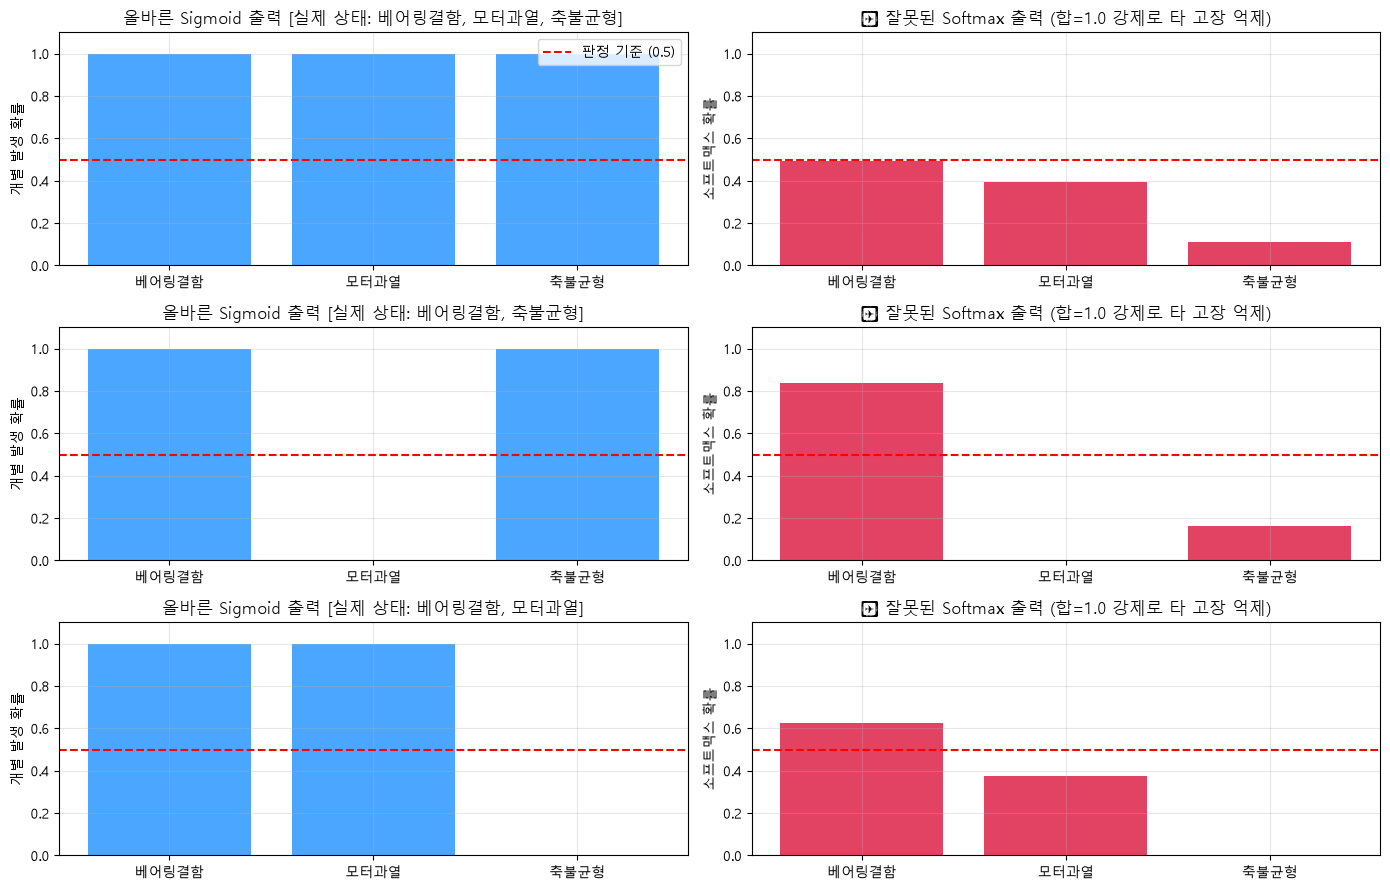

In [11]:
# 테스트셋 중 복합 결함(2개 이상 동시 발생) 샘플 3개 선택
multi_fault_idx = np.where(np.sum(y_ml_test, axis=1) >= 2)[0][:3]

fault_labels = ['베어링결함', '모터과열', '축불균형']

fig, axes = plt.subplots(len(multi_fault_idx), 2, figsize=(14, 3 * len(multi_fault_idx)))

for row, idx in enumerate(multi_fault_idx):
    true_label = y_ml_test[idx]
    x_sample = X_ml_test[idx:idx+1]
    
    corr_pred = correct_ml_model.predict(x_sample)[0]
    wrong_pred = wrong_ml_model.predict(x_sample)[0]
    
    active_str = ", ".join([fault_labels[j] for j in range(3) if true_label[j] == 1])
    
    # 올바른 Sigmoid 모델
    axes[row, 0].bar(fault_labels, corr_pred, color='dodgerblue', alpha=0.8)
    axes[row, 0].axhline(0.5, color='r', linestyle='--', label='판정 기준 (0.5)')
    axes[row, 0].set_ylim(0, 1.1)
    axes[row, 0].set_title(f"올바른 Sigmoid 출력 [실제 상태: {active_str}]")
    axes[row, 0].set_ylabel("개별 발생 확률")
    axes[row, 0].grid(True, alpha=0.3)
    if row == 0: axes[row, 0].legend()
    
    # 잘못된 Softmax 모델
    axes[row, 1].bar(fault_labels, wrong_pred, color='crimson', alpha=0.8)
    axes[row, 1].axhline(0.5, color='r', linestyle='--', label='판정 기준 (0.5)')
    axes[row, 1].set_ylim(0, 1.1)
    axes[row, 1].set_title(f"❌ 잘못된 Softmax 출력 (합=1.0 강제로 타 고장 억제)")
    axes[row, 1].set_ylabel("소프트맥스 확률")
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 5. 🧠 [인터랙티브 퀴즈] 제조 분류 문제별 활성화함수 & 손실함수 매칭

아래 3문항의 제조 분류 시나리오를 읽고, 가장 적합한 **[출력 활성화함수]**와 **[손실함수]**를 골라 아래 코드에 입력 후 채점해 보세요!

---

### [문항 1] 반도체 웨이퍼 양품 vs 불량 2분류 판별
- **상황**: 웨이퍼 표면 검사 이미지 특징으로 양품(0)과 불량(1)을 판별함. 단 하나의 출력 확률값이 필요함.
- **선택지**:
  - 활성화함수: (A) sigmoid, (B) softmax, (C) linear
  - 손실함수: (1) BinaryCrossentropy, (2) CategoricalCrossentropy, (3) MSE

---

### [문항 2] 사출 성형품의 5대 외관 불량 유형 (단일 불량) 판별
- **상황**: 제품당 단 하나의 주요 결함 원인만 존재함 [0: 미성형, 1: 웰드라인, 2: 플래시, 3: 수축, 4: 변형]. 5개 불량 유형의 확률 합은 100%여야 함.
- **선택지**:
  - 활성화함수: (A) sigmoid, (B) softmax, (C) tanh
  - 손실함수: (1) CategoricalCrossentropy, (2) BinaryCrossentropy

---

### [문항 3] 대형 플랜트 펌프의 복합 고장 동시 진단
- **상황**: 펌프에서 [1. 캐비테이션, 2. 베어링 손상, 3. 오일 누유, 4. 모터 과열] 4가지 결함이 독립적으로 동시에 발생할 수 있음.
- **선택지**:
  - 출력층 형태: (A) 4개 뉴런 각각에 Sigmoid, (B) 4개 뉴런 전체에 Softmax
  - 손실함수: (1) BinaryCrossentropy (각 뉴런 독립 합산), (2) CategoricalCrossentropy

---


In [12]:
# 퀴즈 답안 작성
# [완료] 실험으로 확정한 정답 기호
my_answers = {
    'Q1_act': 'A',   # sigmoid : 이진 분류 확률 1개
    'Q1_loss': '1',  # BinaryCrossentropy

    'Q2_act': 'B',   # softmax : 5대 불량이 상호 배타적, 확률 합 100%
    'Q2_loss': '1',  # CategoricalCrossentropy

    'Q3_type': 'A',  # 4개 뉴런 각각 sigmoid : 결함이 독립적으로 동시 발생
    'Q3_loss': '1'   # BinaryCrossentropy (라벨별 독립 합산)
}

answer_key = {
    'Q1_act': ('A', "Sigmoid: 이진 분류(0 vs 1) 확률 출력"),
    'Q1_loss': ('1', "BinaryCrossentropy: 이진 분류의 표준 손실함수"),
    'Q2_act': ('B', "Softmax: 상호 배타적 다중 클래스의 확률 합 1.0 보장"),
    'Q2_loss': ('1', "CategoricalCrossentropy: 다중 클래스 분류 손실"),
    'Q3_type': ('A', "각 뉴런에 Sigmoid: 복합 고장은 독립 사건이므로 독립적 확률 계산 필수"),
    'Q3_loss': ('1', "BinaryCrossentropy: 각 라벨별 독립 BCE 합산")
}

score = 0
print("=" * 65)
print("📝 퀴즈 채점 결과 및 해설")
print("=" * 65)

for q, user_ans in my_answers.items():
    if user_ans == '?':
        print(f"⚠️ [{q}] 아직 풀지 않은 문제입니다.")
        continue
    correct_ans, explanation = answer_key[q]
    if user_ans == correct_ans:
        score += 1
        print(f"✅ [{q}] 정답! -> {explanation}")
    else:
        print(f"❌ [{q}] 오답 (작성: {user_ans}) -> 정답: {correct_ans} | 해설: {explanation}")

print("-" * 65)
print(f"🏆 총점: {score} / {len(my_answers)} ({score/len(my_answers)*100:.1f}점)")
print("=" * 65)


📝 퀴즈 채점 결과 및 해설
✅ [Q1_act] 정답! -> Sigmoid: 이진 분류(0 vs 1) 확률 출력
✅ [Q1_loss] 정답! -> BinaryCrossentropy: 이진 분류의 표준 손실함수
✅ [Q2_act] 정답! -> Softmax: 상호 배타적 다중 클래스의 확률 합 1.0 보장
✅ [Q2_loss] 정답! -> CategoricalCrossentropy: 다중 클래스 분류 손실
✅ [Q3_type] 정답! -> 각 뉴런에 Sigmoid: 복합 고장은 독립 사건이므로 독립적 확률 계산 필수
✅ [Q3_loss] 정답! -> BinaryCrossentropy: 각 라벨별 독립 BCE 합산
-----------------------------------------------------------------
🏆 총점: 6 / 6 (100.0점)


> **[퀴즈 답안 근거]**
>
> | 문항 | 답 | 근거 |
> |:--|:--:|:--|
> | Q1 | **A / 1** | sigmoid F1 0.9440, 확률범위 이탈 0%. softmax(뉴런 1개)는 출력이 상수 1.000 |
> | Q2 | **B / 1** | 정확도는 softmax·sigmoid 동률(0.8100). 갈린 지점은 **단일 판정 실패율 2.0% vs 7.5%** |
> | Q3 | **A / 1** | 복합결함 검출 **163/163(100%) vs 52/163(31.9%)**, micro-F1 3.2배 차이 |
>
> **Q2 보충**: 정확도만 보면 두 선택지가 같습니다. 문항의 요구사항인
> *"5개 불량 유형의 확률 합은 100%여야 한다"* 와 *"제품당 단 하나의 원인"* 을
> 만족하려면, "0.5 를 넘는 라벨이 0개이거나 2개 이상"인 **판정 불가 샘플**이
> 적어야 합니다. sigmoid 는 이 비율이 7.5% 로 softmax(2.0%)의 **3.75배** 입니다.
>
> **판단 기준 한 줄**: *"클래스들이 서로 배타적인가?"*
> Yes → softmax (경쟁) · No → sigmoid (독립)

---
## 6. 실습 정리 및 결론

| 분류 유형 | 대상 제조 문제 | 출력 뉴런 수 | 출력 활성화함수 | 적합한 손실함수 |
|:---|:---|:---:|:---:|:---|
| **이진 분류 (Binary)** | 양품 vs 불량 판별 | 1 | `Sigmoid` | `BinaryCrossentropy` |
| **다중 클래스 (Multi-Class)** | 상호 배타적 결함 유형 4종 진단 | $K$ (클래스수) | `Softmax` | `CategoricalCrossentropy` |
| **다중 라벨 (Multi-Label)** | 복합 동시 발생 고장 진단 | $M$ (고장종류) | 각 뉴런 `Sigmoid` | `BinaryCrossentropy` |

- 제조 도메인의 문제 특성(단일 고장인가, 복합 고장인가)을 사전에 명확히 분석하고 활성화함수와 손실함수를 짝지어야 합니다.
